In [1]:
import gifba
from scipy.integrate import solve_ivp
import numpy as np
import cobra as cb
import pandas as pd
from IPython.display import clear_output
import copy

In [2]:
def rename_community_biomass(models, old_biomass_id="EX_Bio(e)"):
    """
    Renames the biomass exchange reactions and their associated metabolites 
    to track individual species separately.
    """
    # Deepcopy ensures we don't accidentally modify the original template models
    updated_models = copy.deepcopy(models)
    
    for idx, model in enumerate(updated_models):
        suffix = f"_{idx + 1}"  # e.g., _1, _2
        
        if old_biomass_id in model.reactions:
            # 1. Isolate the biomass reaction
            biomass_rxn = model.reactions.get_by_id(old_biomass_id)
            
            # 2. Rename the associated biomass metabolite(s) FIRST
            # We cast to list() to avoid modifying a dictionary while iterating over it
            for metabolite in list(biomass_rxn.metabolites):
                metabolite.id = f"{metabolite.id}{suffix}"
                # Optional: update the metabolite name for clarity
                metabolite.name = f"{metabolite.name} (Species {idx + 1})"
            
            # 3. Rename the reaction itself
            biomass_rxn.id = f"{old_biomass_id}{suffix}"
            biomass_rxn.name = f"{biomass_rxn.name} (Species {idx + 1})"
            
    return updated_models

In [3]:

# models, media = gifba.utils.load_simple_models("2_1_competition")
# models, media = gifba.utils.load_simple_models("3_1_crossfeed")
models, media = gifba.utils.load_simple_models("5_1_coupling")
renamed_models = rename_community_biomass(models, old_biomass_id="EX_Bio(e)")


community = gifba.gifbaObject(renamed_models, media, [0.8, 0.2])
_, _ = community.run_gifba(iters=1, method="pfba", v=False)
clear_output()

# equal rel_abund
rel_abund = community.rel_abund.copy()


# def params
diff_coef = 0.1  # Diffusion coefficient

# media from gifba
substrate_0 = community.env_fluxes.loc[0, :].to_dict()
substrate_0

# kinetic params
V_MAX_ALL = 1000  # Maximum uptake rate for all substrates
K_M_ALL = 0.1  # Michaelis-Menten constant for all substrates
vmax_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), V_MAX_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(models))])
km_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), K_M_ALL),
                              columns=list(substrate_0.keys()),
                              index=[str(mdl_idx) for mdl_idx in range(len(models))])


    


In [8]:
def dsdt(t, S, models, vmax, km, media_vals, media_keys, dilution_rate):
    # Initialize the rate of change for each metabolite to 0
    dsdt_rates = np.zeros(len(S))
    
    # Create a mapping for quick lookup: {metabolite_id: current_concentration}
    conc_map = dict(zip(media_keys, S))
    
    for mdl_idx, model in enumerate(models):
        # 1. Update lower bounds based on Michaelis-Menten kinetics
        for ex_id in media_keys:
            if ex_id in model.reactions and "bio" not in ex_id:
                v_max = vmax.loc[str(mdl_idx), ex_id]
                k_m = km.loc[str(mdl_idx), ex_id]
                c = conc_map[ex_id]
                
                if c < 1e-6:
                    c = 0.0  # Avoid very small concentrations causing numerical errors

                # Michaelis-Menten uptake limit 
                uptake_limit = (v_max * c) / (k_m + c)
                
                # In COBRA, uptake is negative, so lower_bound is -uptake_limit
                model.reactions.get_by_id(ex_id).lower_bound = -uptake_limit / rel_abund[mdl_idx]  # Scale by relative abundance

        # 2. Run FBA
        solution = model.optimize()

        # 3. Add fluxes to the net rate of change (weighted by clamped relative abundance)
        if solution.status == 'optimal':
            for i, ex_id in enumerate(media_keys):
                # Convert flux to per second (assuming original is per hour)
                flux_per_hr = solution.fluxes.get(ex_id, 0)
                
                # We add the RATE of change to our array. solve_ivp handles the integration over time.
                if "bio" not in ex_id.lower():
                    dsdt_rates[i] += flux_per_hr * rel_abund[mdl_idx]  # + media flux, keep dsdt for bio = 0

    for ex_idx, ex_id in enumerate(media_keys):
        if "bio" not in ex_id.lower():
            # dsdt_rates[ex_idx] += media_vals[ex_idx]
            dsdt_rates[ex_idx] += media_vals[ex_idx]  - dilution_rate * conc_map[ex_id]  # Dilution effect

    return dsdt_rates

# Preparing cleaner inputs for solve_ivp
m_keys = list(substrate_0.keys()) 
m_vals = np.array([substrate_0[k] for k in m_keys]) # scaled to per second
y0 = np.zeros(len(m_keys))  # Initial concentrations of substrates
D = 0.1  # Example dilution rate

sol = solve_ivp(
    dsdt,
    t_span=(0, 100),
    y0=y0,
    args=(copy.deepcopy(renamed_models), vmax_vals, km_vals, m_vals, m_keys, D),
    method='BDF' # BDF is excellent for stiff biological ODEs
)

for idx, key in enumerate(m_keys):
    print(f"{key}: {sol.y[idx, -1]}")  # Print final concentration of each substrate
    

Read LP format model from file /tmp/tmpn9h9mib9.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmp57grgt9n.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
EX_Bio(e)_2: 0.0
EX_Bio(e)_1: 0.0
EX_A(e): 0.0005025125627884362
EX_B(e): 0.000502507487083664


In [9]:
import pandas as pd

# 1. Extract the final concentrations from the end of the simulation
final_concentrations = sol.y[:, -1]
final_conc_map = dict(zip(m_keys, final_concentrations))

# Dictionary to store the resulting flux profiles
final_fluxes = {}


for mdl_idx, model in enumerate(renamed_models):
    # 2. Re-apply the Michaelis-Menten bounds using the final concentrations
    for ex_id in m_keys:
        if ex_id in model.reactions and "bio" not in ex_id:
            # Note: Make sure the variable names match what you passed to solve_ivp
            v_max = vmax_vals.loc[str(mdl_idx), ex_id]
            k_m = km_vals.loc[str(mdl_idx), ex_id]
            c = final_conc_map[ex_id]
            
            if c < 1e-6:
                c = 0.0

            uptake_limit = (v_max * c) / (k_m + c)
            print(f"Model_{mdl_idx}, Reaction {ex_id}: Final concentration = {c}, Uptake limit = {uptake_limit}")
            
            # Applying the bound (assuming the double-scaling issue is resolved)
            model.reactions.get_by_id(ex_id).lower_bound = -uptake_limit / rel_abund[mdl_idx] # Scale by relative abundance
            
    # 3. Run FBA for the final state
    solution = model.optimize()
    
    # 4. Save the fluxes 
    if solution.status == 'optimal':
        # Convert the pandas Series to a dictionary for easy aggregation
        print(solution.fluxes)
        solution_flux_dict = solution.fluxes.to_dict()
        scaled_flux_dict = {rxn: flux * rel_abund[mdl_idx] for rxn, flux in solution_flux_dict.items()}
        final_fluxes[f"Model_{mdl_idx}"] = scaled_flux_dict
    else:
        print(f"Warning: Model_{mdl_idx} did not find an optimal solution at the final state.")
        final_fluxes[f"Model_{mdl_idx}"] = None

# 5. Compile everything into a DataFrame for easy viewing and export
# Rows will be reactions, columns will be your bacterial models
flux_df = pd.DataFrame(final_fluxes).fillna(0.0)

# Display the first few rows
print(flux_df)

Model_0, Reaction EX_Bio(e)_1: Final concentration = 0.0, Uptake limit = 0.0
Model_0, Reaction EX_A(e): Final concentration = 0.0005025125627884362, Uptake limit = 4.999999999746215
Model_0, Reaction EX_B(e): Final concentration = 0.000502507487083664, Uptake limit = 4.999949748997507
EX_A(e)       -6.25
EX_B(e)        6.25
T_A            6.25
T_B            6.25
T_Bio          6.25
Biomass(c)     6.25
EX_Bio(e)_1    6.25
Name: fluxes, dtype: float64
Model_1, Reaction EX_Bio(e)_2: Final concentration = 0.0, Uptake limit = 0.0
Model_1, Reaction EX_A(e): Final concentration = 0.0005025125627884362, Uptake limit = 4.999999999746215
Model_1, Reaction EX_B(e): Final concentration = 0.000502507487083664, Uptake limit = 4.999949748997507
EX_B(e)       -24.999749
EX_A(e)       -24.999749
T_B            24.999749
T_A            24.999749
Biomass(c)     24.999749
T_Bio          24.999749
EX_Bio(e)_2    24.999749
Name: fluxes, dtype: float64
                          Model_0               Model_1

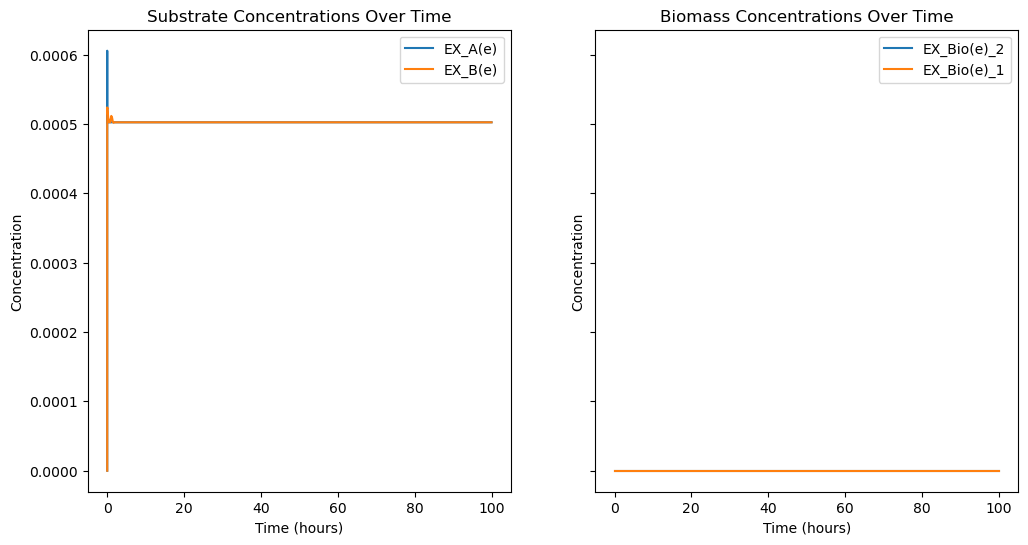

In [10]:
# plot each metabolite's concentration over time
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=True)
for i, metabolite in enumerate(m_keys):
    if "Bio" in metabolite:
        ax[1].plot(sol.t, sol.y[i], label=metabolite)
        ax[1].set_xlabel('Time (hours)')
        ax[1].set_ylabel('Concentration')
        ax[1].set_title('Biomass Concentrations Over Time')
        ax[1].legend()
    else:
        ax[0].plot(sol.t, sol.y[i], label=metabolite)
        ax[0].set_xlabel('Time (hours)')
        ax[0].set_ylabel('Concentration')
        ax[0].set_title('Substrate Concentrations Over Time')
        ax[0].legend()

Read LP format model from file /tmp/tmpvp03hqxh.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros
Read LP format model from file /tmp/tmphxyhspey.lp
Reading time = 0.00 seconds
: 4 rows, 10 columns, 16 nonzeros


TypeError: dsdt() missing 2 required positional arguments: 'media_keys' and 'dilution_rate'

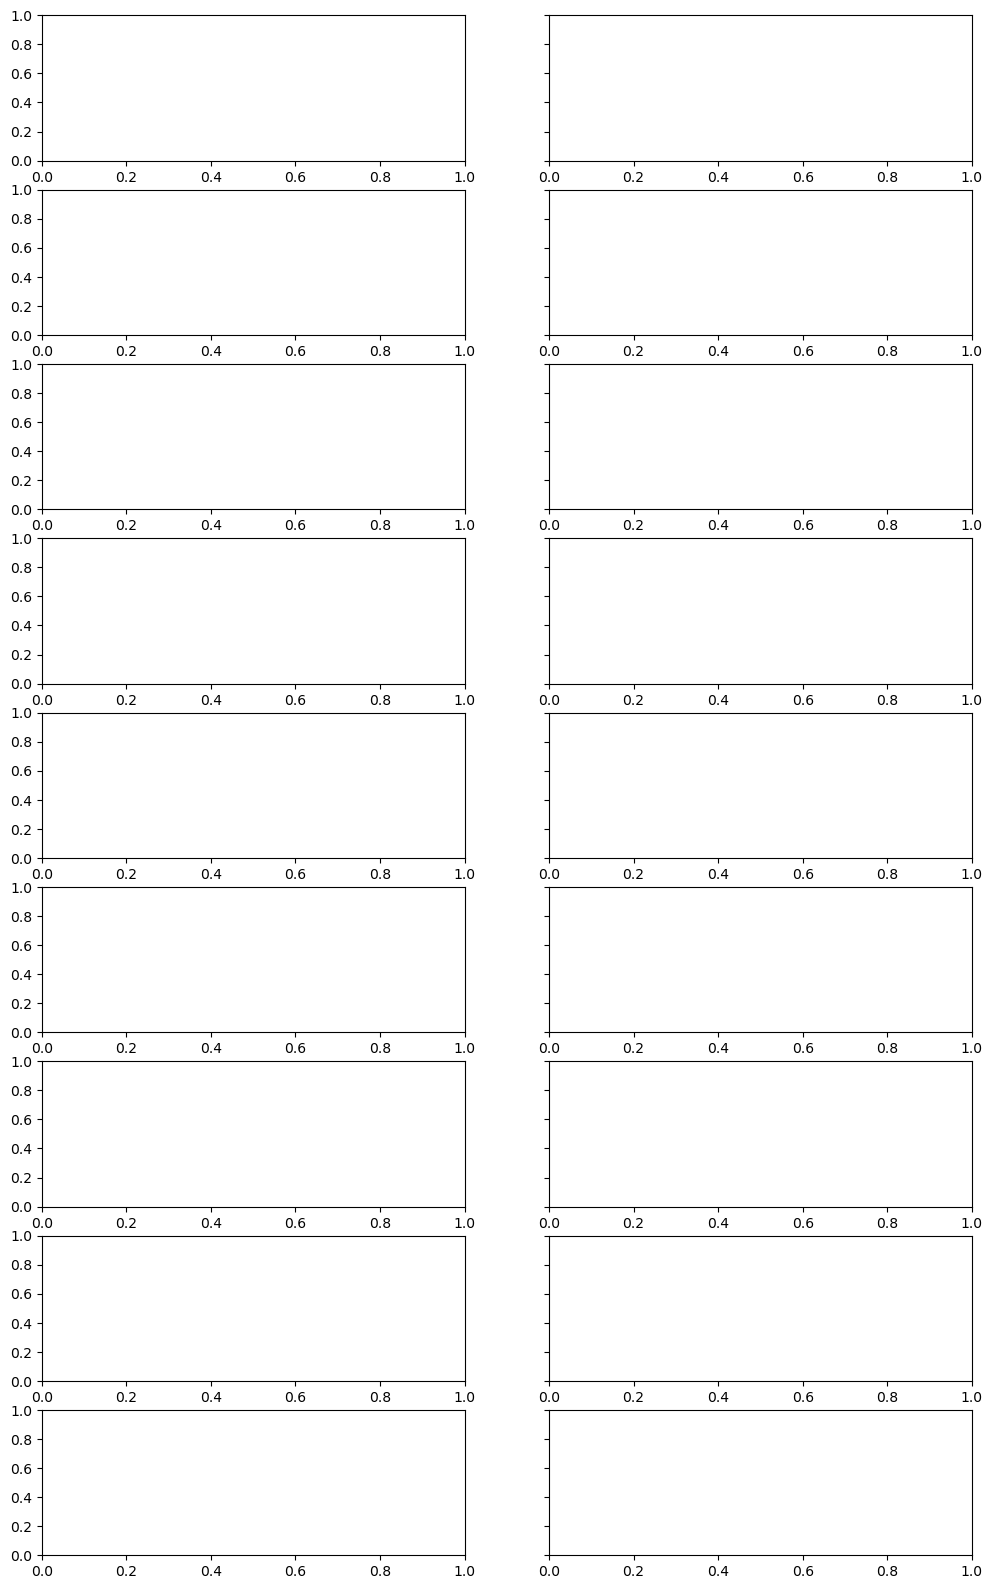

In [8]:
# run clamped dfba for all simulations
sims = ["1_3_parallel",
        "2_1_competition",
        "3_1_crossfeed",
        "3_2_layered",
        "4_1_crossfeed_competition",
        "4_2_superfluous_crossfeed",
        "4_3_efficient_crossfeed",
        "5_1_coupling",
        "5_2_dynamical"]
fig, ax = plt.subplots(nrows=len(sims), ncols=2, figsize=(12, 20), sharey=True, clear=True)
ax = ax.flatten()

for sim_idx, sim in enumerate(sims):
    print(f"Running simulation {sim_idx + 1}: {sim}")
    models, media = gifba.utils.load_simple_models(sim)
    renamed_models = rename_community_biomass(models, old_biomass_id="EX_Bio(e)")


    community = gifba.gifbaObject(renamed_models, media, [0.5, 0.5])
    _, _ = community.run_gifba(iters=1, method="pfba", v=False)
    clear_output()

    # equal rel_abund
    rel_abund = community.rel_abund.copy()


    # def params
    diff_coef = 0.1  # Diffusion coefficient

    # media from gifba
    substrate_0 = community.env_fluxes.loc[0, :].to_dict()
    substrate_0

    # kinetic params
    V_MAX_ALL = 1000  # Maximum uptake rate for all substrates
    K_M_ALL = 0.1  # Michaelis-Menten constant for all substrates
    vmax_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), V_MAX_ALL),
                                columns=list(substrate_0.keys()),
                                index=[str(mdl_idx) for mdl_idx in range(len(models))])
    km_vals = pd.DataFrame(np.full((len(models), len(substrate_0.keys())), K_M_ALL),
                                columns=list(substrate_0.keys()),
                                index=[str(mdl_idx) for mdl_idx in range(len(models))])


        
    # Preparing cleaner inputs for solve_ivp
    m_keys = list(substrate_0.keys()) 
    m_vals = np.array([substrate_0[k] for k in m_keys]) 
    y0 = m_vals.copy()

    sol = solve_ivp(
        dsdt,
        t_span=(0, 100),
        y0=y0,
        args=(copy.deepcopy(renamed_models), vmax_vals, km_vals, m_keys),
        method='BDF' # BDF is excellent for stiff biological ODEs
    )


    for i, metabolite in enumerate(m_keys):
        if "Bio" in metabolite:
            ax[2*sim_idx+1].plot(sol.t, sol.y[i], label=metabolite)
            ax[2*sim_idx+1].set_xlabel('Time (hours)')
            ax[2*sim_idx+1].set_ylabel('Concentration')
            ax[2*sim_idx+1].legend()
        else:
            ax[2*sim_idx].plot(sol.t, sol.y[i], label=metabolite)
            ax[2*sim_idx].set_xlabel('Time (hours)')
            ax[2*sim_idx].set_ylabel('Concentration')
            ax[2*sim_idx].set_title('Simulation: ' + sim)
            ax[2*sim_idx].legend()
plt.tight_layout()